FL on MNIST / Fashion-MNIST / CIFAR-10 — IID and Label-Skew Non-IID Notebook Guide

In [ ]:
import argparse  # for command-line argument parsing
import copy  # for deep copying objects
import random  # for random number generation
from collections import OrderedDict, defaultdict # for ordered dictionaries and default dictionaries
# ordered dictionaries to maintain the order of keys and default dictionaries to provide default values for missing keys
# defaultdict is a subclass of the built-in dict class that returns a default value when a key is not found, instead of raising a KeyError
import matplotlib.pyplot as plt  # for plotting results
import numpy as np  # for numerical operations
import pandas as pd
import torch
from torch import nn
from torch.optim import SGD
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


Cell 2 — Reproducibility

In [95]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Cell 3 — Model: 2NN

Why 2NN first:

easier to debug than CNN
faster to run
enough to clearly show IID vs non-IID behavior in FL

In [ ]:
class TwoNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=200, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


Cell 4 — Model parameter utilities

In [97]:
def get_model_params(model: nn.Module):
    return OrderedDict((k, v.detach().clone()) for k, v in model.state_dict().items())


def set_model_params(model: nn.Module, params):
    model.load_state_dict(params, strict=True)


def subtract_params(new_params, old_params):
    return OrderedDict((k, new_params[k] - old_params[k]) for k in new_params.keys())


def add_params(a, b):
    return OrderedDict((k, a[k] + b[k]) for k in a.keys())


def scale_params(params, scalar: float):
    return OrderedDict((k, v * scalar) for k, v in params.items())


def zeros_like_params(params):
    return OrderedDict((k, torch.zeros_like(v)) for k, v in params.items())

Cell 5 — Dataset loading helpers

In [98]:
def get_dataset_config(dataset_name: str):
    dataset_name = dataset_name.lower()

    if dataset_name == "mnist":
        transform = transforms.ToTensor()
        dataset_cls = datasets.MNIST
        input_dim = 1 * 28 * 28
        num_classes = 10

    elif dataset_name == "fmnist":
        transform = transforms.ToTensor()
        dataset_cls = datasets.FashionMNIST
        input_dim = 1 * 28 * 28
        num_classes = 10

    elif dataset_name == "cifar10":
        transform = transforms.ToTensor()
        dataset_cls = datasets.CIFAR10
        input_dim = 3 * 32 * 32
        num_classes = 10

    else:
        raise ValueError("dataset_name must be one of: 'mnist', 'fmnist', 'cifar10'")

    return {
        "dataset_cls": dataset_cls,
        "transform": transform,
        "input_dim": input_dim,
        "num_classes": num_classes,
    }


def load_dataset(dataset_name: str, data_root: str = "./data"):
    cfg = get_dataset_config(dataset_name)
    dataset_cls = cfg["dataset_cls"]
    transform = cfg["transform"]

    train_ds = dataset_cls(root=data_root, train=True, download=True, transform=transform)
    test_ds = dataset_cls(root=data_root, train=False, download=True, transform=transform)
    return train_ds, test_ds, cfg


Cell 6 — Stage 1 data partition: IID

This shuffles all training samples and splits them equally among 10 clients.

In [99]:
def partition_iid(dataset, num_clients=10, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    shard_size = len(indices) // num_clients
    subsets = []
    for i in range(num_clients):
        start = i * shard_size
        end = (i + 1) * shard_size if i < num_clients - 1 else len(indices)
        subsets.append(Subset(dataset, indices[start:end].tolist()))
    return subsets

Cell 7 — Label-skew non-IID partition (k labels per client)

In [ ]:
def _get_targets(dataset):
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            return targets.tolist()
        return list(targets)

    targets = []
    for _, label in dataset:
        targets.append(int(label))
    return targets


def partition_label_skew(dataset, num_clients=10, labels_per_client=1, seed=42):
    if labels_per_client < 1 or labels_per_client > 10:
        raise ValueError("labels_per_client must be between 1 and 10")

    targets = _get_targets(dataset)
    label_to_indices = defaultdict(list)

    for idx, label in enumerate(targets):
        label_to_indices[int(label)].append(idx)

    rng = np.random.default_rng(seed)
    for label in label_to_indices:
        rng.shuffle(label_to_indices[label])

    client_labels = {
        client_id: sorted({(client_id + offset) % 10 for offset in range(labels_per_client)})
        for client_id in range(num_clients)
    }

    label_to_clients = defaultdict(list)  # this part is crucial for the partitioning logic, it maps each label to the clients that have that label in their assigned set of labels
    for client_id, labels in client_labels.items():
        for label in labels:
            label_to_clients[label].append(client_id)

    client_indices = {client_id: [] for client_id in range(num_clients)}

    for label, indices in label_to_indices.items():
        assigned_clients = label_to_clients[label]
        splits = np.array_split(indices, len(assigned_clients))
        for client_id, split in zip(assigned_clients, splits):
            client_indices[client_id].extend(split.tolist())

    subsets = []
    for client_id in range(num_clients):
        rng.shuffle(client_indices[client_id])
        subsets.append(Subset(dataset, client_indices[client_id]))

    return subsets


Cell 8 — DataLoaders

In [101]:
def make_loaders(train_subsets, test_ds, batch_size=64, test_batch_size=256):
    train_loaders = [
        DataLoader(subset, batch_size=batch_size, shuffle=True)
        for subset in train_subsets
    ]
    test_loader = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    return train_loaders, test_loader

Cell 9 — FL Client

Each client:

receives global parameters
trains locally
computes update = final params - initial params

In [102]:
class FLClient:
    def __init__(self, client_id, model, loader, lr, local_epochs, device):
        self.client_id = client_id
        self.model = model.to(device)
        self.loader = loader
        self.lr = lr
        self.local_epochs = local_epochs
        self.device = device

    def train(self, global_params):
        set_model_params(self.model, global_params)
        initial_params = get_model_params(self.model)

        self.model.train()
        optimizer = SGD(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        loss_sum = 0.0
        count = 0

        for _ in range(self.local_epochs):
            for x, y in self.loader:
                x, y = x.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                logits = self.model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                loss_sum += loss.item() * y.size(0)
                count += y.size(0)

        final_params = get_model_params(self.model)
        update = subtract_params(final_params, initial_params)

        return {
            "client_id": self.client_id,
            "num_samples": len(self.loader.dataset),
            "update": update,
            "local_loss": loss_sum / max(count, 1),
        }

Cell 10 — FL Server (FedAvg)

In [ ]:
class FLServer:
    def __init__(self, initial_params):
        self.global_params = initial_params

    def aggregate(self, client_results): # this method takes the updates from the clients and aggregates them to update the global model parameters, it uses a weighted average based on the number of samples each client has to ensure that clients with more data have a greater influence on the global model update
        total_samples = sum(r["num_samples"] for r in client_results)
        agg_update = zeros_like_params(client_results[0]["update"])

        for result in client_results:
            weight = result["num_samples"] / total_samples
            weighted_update = scale_params(result["update"], weight)
            agg_update = add_params(agg_update, weighted_update)

        self.global_params = add_params(self.global_params, agg_update)

Cell 11 — Evaluation

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    correct = 0  # count of correct predictions
    total = 0  # total number of samples
    loss_sum = 0.0  # sum of losses

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)  #y.size(0) gives the number of samples in the current batch, we add this to the total count of samples
            loss_sum += loss.item() * y.size(0)

    return {
        "accuracy": correct / total,
        "loss": loss_sum / total,
    }

Cell 12 — Main experiment runner (generic across datasets)

In [ ]:
def run_federated_experiment(
    dataset_name: str,
    stage: str,
    data_root: str = "./data",
    num_clients: int = 10,
    rounds: int = 100,
    batch_size: int = 64,
    test_batch_size: int = 256,
    lr: float = 0.1,
    local_epochs: int = 5,
    hidden_dim: int = 200,
    seed: int = 42,
    device: str = "cpu",
    labels_per_client: int = 1,
):
    set_seed(seed)

    # load the specified dataset and get its configuration, this includes the training and test datasets, as well as the input dimension and number of classes which are needed to define the model architecture
    train_ds, test_ds, cfg = load_dataset(dataset_name, data_root)
    input_dim = cfg["input_dim"]
    num_classes = cfg["num_classes"]

    dataset_tag = dataset_name.lower()

    # create the data partitions for each client based on the specified stage (iid or label_noniid), this will determine how the training data is distributed among the clients, and it will also set the title and output file names for the results based on the stage and dataset
    if stage == "iid":
        train_subsets = partition_iid(train_ds, num_clients=num_clients, seed=seed)
        title = f"{dataset_name.upper()} — IID FL"
        out_plot = f"{dataset_tag}_iid_accuracy_vs_round.png"
        out_csv = f"{dataset_tag}_iid_metrics.csv"

    elif stage == "label_noniid":
        train_subsets = partition_label_skew(
            train_ds,
            num_clients=num_clients,
            labels_per_client=labels_per_client,
            seed=seed,
        )
        title = f"{dataset_name.upper()} — Label-skew Non-IID ({labels_per_client} labels/client)"
        out_plot = f"{dataset_tag}_label_noniid_{labels_per_client}labels_accuracy_vs_round.png"
        out_csv = f"{dataset_tag}_label_noniid_{labels_per_client}labels_metrics.csv"

    else:
        raise ValueError("stage must be either 'iid' or 'label_noniid'")

    # train loader is a list of data loaders, one for each client, created from the respective subsets of the training dataset, while the test loader is a single data loader for the entire test dataset
    train_loaders, test_loader = make_loaders(
        train_subsets,
        test_ds,
        batch_size=batch_size,
        test_batch_size=test_batch_size,
    )

    # initialize the global model parameters using a base model, this ensures that all clients start with the same global model parameters at the beginning of each round, and the server will maintain and update these global parameters based on the updates received from the clients
    base_model = TwoNN(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
    ).to(device)

    initial_params = get_model_params(base_model)
    server = FLServer(initial_params=initial_params)

    # Create a list of clients with their respective data loaders and the same initial model architecture, each client will start with the same global model parameters at the beginning of each round
    clients = [
        FLClient(
            client_id=i,
            model=TwoNN(
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                num_classes=num_classes,
            ),
            loader=train_loaders[i],
            lr=lr,
            local_epochs=local_epochs,
            device=device,
        )
        for i in range(num_clients)
    ]

    history = [] # 

    for rnd in range(1, rounds + 1):
        global_params = copy.deepcopy(server.global_params)

        client_results = []
        for client in clients:
            result = client.train(global_params)
            client_results.append(result)

        server.aggregate(client_results) # after collecting the updates from all clients, the server aggregates these updates to update the global model parameters, this is done by calling the aggregate method of the FLServer class, which takes the client results and computes a weighted average of the updates based on the number of samples each client has

        eval_model = TwoNN(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_classes=num_classes,
        ).to(device)
        
        set_model_params(eval_model, server.global_params)
        eval_result = evaluate(eval_model, test_loader, device=device)

        avg_local_loss = sum(r["local_loss"] for r in client_results) / len(client_results)

        history.append(
            {
                "round": rnd,
                "dataset": dataset_name.lower(),
                "stage": stage,
                "labels_per_client": labels_per_client if stage == "label_noniid" else num_classes,
                "test_accuracy": eval_result["accuracy"],
                "test_loss": eval_result["loss"],
                "avg_client_local_loss": avg_local_loss,
                "lr": lr,
                "batch_size": batch_size,
                "local_epochs": local_epochs,
            }
        )

        print(
            f"{dataset_name.upper()} | {stage} | Round {rnd:02d} | "
            f"test_acc={eval_result['accuracy']:.4f} | "
            f"test_loss={eval_result['loss']:.4f} | "
            f"avg_local_loss={avg_local_loss:.4f}"
        )

    df = pd.DataFrame(history)
    df.to_csv(out_csv, index=False)

    plt.figure(figsize=(8, 4))
    plt.plot(df["round"], df["test_accuracy"], marker="o")
    plt.xlabel("Training Round")
    plt.ylabel("Test Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_plot)
    plt.show()

    print(f"\nSaved metrics to: {out_csv}")
    print(f"Saved plot to:    {out_plot}")

    return df


Cell 13 — Device setup

In [106]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


Cell 14 

MNIST | iid | Round 01 | test_acc=0.9157 | test_loss=0.3013 | avg_local_loss=0.5630
MNIST | iid | Round 02 | test_acc=0.9317 | test_loss=0.2417 | avg_local_loss=0.2710
MNIST | iid | Round 03 | test_acc=0.9433 | test_loss=0.2027 | avg_local_loss=0.2153
MNIST | iid | Round 04 | test_acc=0.9489 | test_loss=0.1755 | avg_local_loss=0.1782
MNIST | iid | Round 05 | test_acc=0.9542 | test_loss=0.1559 | avg_local_loss=0.1516
MNIST | iid | Round 06 | test_acc=0.9591 | test_loss=0.1409 | avg_local_loss=0.1309
MNIST | iid | Round 07 | test_acc=0.9622 | test_loss=0.1300 | avg_local_loss=0.1150
MNIST | iid | Round 08 | test_acc=0.9653 | test_loss=0.1195 | avg_local_loss=0.1022
MNIST | iid | Round 09 | test_acc=0.9665 | test_loss=0.1117 | avg_local_loss=0.0917
MNIST | iid | Round 10 | test_acc=0.9679 | test_loss=0.1057 | avg_local_loss=0.0829
MNIST | iid | Round 11 | test_acc=0.9707 | test_loss=0.1005 | avg_local_loss=0.0757
MNIST | iid | Round 12 | test_acc=0.9723 | test_loss=0.0967 | avg_local_loss

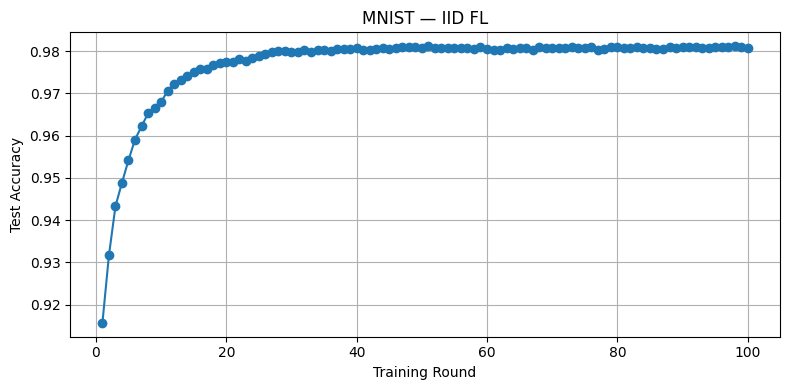


Saved metrics to: mnist_iid_metrics.csv
Saved plot to:    mnist_iid_accuracy_vs_round.png
MNIST | label_noniid | Round 01 | test_acc=0.2449 | test_loss=2.2156 | avg_local_loss=0.0128
MNIST | label_noniid | Round 02 | test_acc=0.3556 | test_loss=2.1225 | avg_local_loss=0.0076
MNIST | label_noniid | Round 03 | test_acc=0.4564 | test_loss=2.0418 | avg_local_loss=0.0061
MNIST | label_noniid | Round 04 | test_acc=0.5378 | test_loss=1.9710 | avg_local_loss=0.0054
MNIST | label_noniid | Round 05 | test_acc=0.5860 | test_loss=1.9067 | avg_local_loss=0.0049
MNIST | label_noniid | Round 06 | test_acc=0.6208 | test_loss=1.8457 | avg_local_loss=0.0046
MNIST | label_noniid | Round 07 | test_acc=0.6615 | test_loss=1.7841 | avg_local_loss=0.0044
MNIST | label_noniid | Round 08 | test_acc=0.6658 | test_loss=1.7287 | avg_local_loss=0.0042
MNIST | label_noniid | Round 09 | test_acc=0.6840 | test_loss=1.6749 | avg_local_loss=0.0041
MNIST | label_noniid | Round 10 | test_acc=0.6761 | test_loss=1.6242 | a

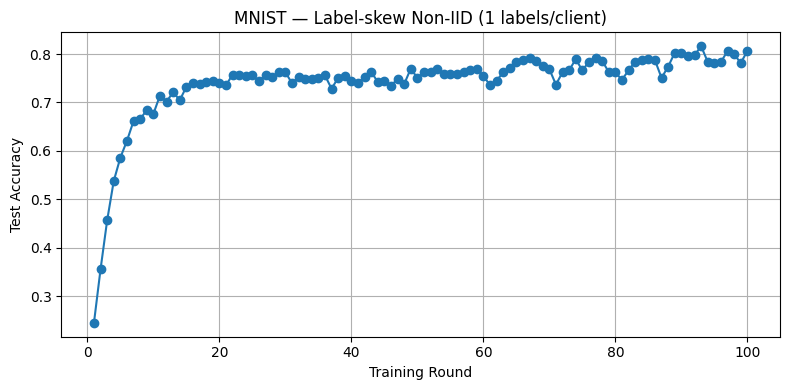


Saved metrics to: mnist_label_noniid_1labels_metrics.csv
Saved plot to:    mnist_label_noniid_1labels_accuracy_vs_round.png
MNIST | label_noniid | Round 01 | test_acc=0.5113 | test_loss=1.9147 | avg_local_loss=0.0709
MNIST | label_noniid | Round 02 | test_acc=0.6511 | test_loss=1.5073 | avg_local_loss=0.0536
MNIST | label_noniid | Round 03 | test_acc=0.7340 | test_loss=1.1991 | avg_local_loss=0.0473
MNIST | label_noniid | Round 04 | test_acc=0.7544 | test_loss=1.0057 | avg_local_loss=0.0428
MNIST | label_noniid | Round 05 | test_acc=0.7680 | test_loss=0.8848 | avg_local_loss=0.0388
MNIST | label_noniid | Round 06 | test_acc=0.7779 | test_loss=0.7975 | avg_local_loss=0.0364
MNIST | label_noniid | Round 07 | test_acc=0.7868 | test_loss=0.7346 | avg_local_loss=0.0336
MNIST | label_noniid | Round 08 | test_acc=0.7982 | test_loss=0.6891 | avg_local_loss=0.0326
MNIST | label_noniid | Round 09 | test_acc=0.8056 | test_loss=0.6501 | avg_local_loss=0.0296
MNIST | label_noniid | Round 10 | test

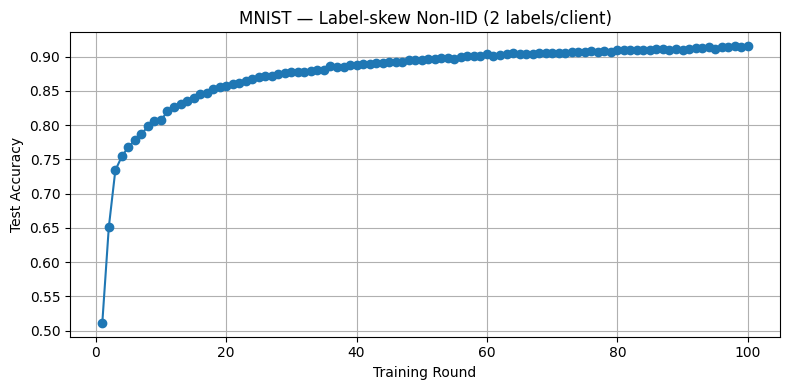


Saved metrics to: mnist_label_noniid_2labels_metrics.csv
Saved plot to:    mnist_label_noniid_2labels_accuracy_vs_round.png
MNIST | label_noniid | Round 01 | test_acc=0.8330 | test_loss=1.1680 | avg_local_loss=0.2010
MNIST | label_noniid | Round 02 | test_acc=0.8761 | test_loss=0.6241 | avg_local_loss=0.1368
MNIST | label_noniid | Round 03 | test_acc=0.8919 | test_loss=0.4490 | avg_local_loss=0.1124
MNIST | label_noniid | Round 04 | test_acc=0.9044 | test_loss=0.3681 | avg_local_loss=0.0976
MNIST | label_noniid | Round 05 | test_acc=0.9135 | test_loss=0.3224 | avg_local_loss=0.0858
MNIST | label_noniid | Round 06 | test_acc=0.9172 | test_loss=0.2944 | avg_local_loss=0.0771
MNIST | label_noniid | Round 07 | test_acc=0.9223 | test_loss=0.2724 | avg_local_loss=0.0702
MNIST | label_noniid | Round 08 | test_acc=0.9257 | test_loss=0.2553 | avg_local_loss=0.0640
MNIST | label_noniid | Round 09 | test_acc=0.9287 | test_loss=0.2421 | avg_local_loss=0.0587
MNIST | label_noniid | Round 10 | test

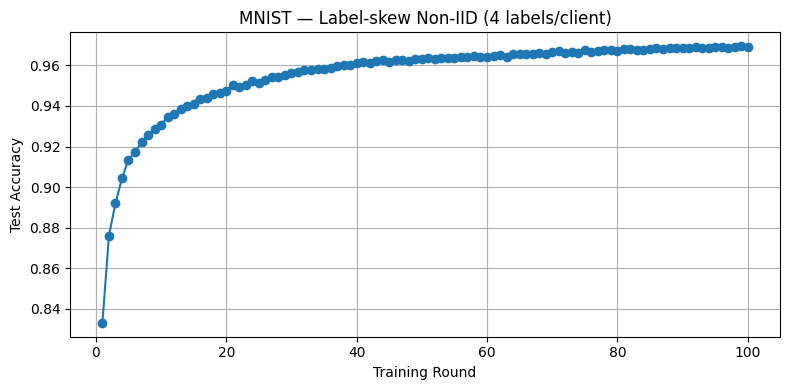


Saved metrics to: mnist_label_noniid_4labels_metrics.csv
Saved plot to:    mnist_label_noniid_4labels_accuracy_vs_round.png
MNIST | label_noniid | Round 01 | test_acc=0.8756 | test_loss=0.6559 | avg_local_loss=0.3296
MNIST | label_noniid | Round 02 | test_acc=0.9144 | test_loss=0.3474 | avg_local_loss=0.2001
MNIST | label_noniid | Round 03 | test_acc=0.9240 | test_loss=0.2754 | avg_local_loss=0.1612
MNIST | label_noniid | Round 04 | test_acc=0.9326 | test_loss=0.2385 | avg_local_loss=0.1373
MNIST | label_noniid | Round 05 | test_acc=0.9398 | test_loss=0.2137 | avg_local_loss=0.1194
MNIST | label_noniid | Round 06 | test_acc=0.9440 | test_loss=0.1967 | avg_local_loss=0.1062
MNIST | label_noniid | Round 07 | test_acc=0.9473 | test_loss=0.1797 | avg_local_loss=0.0951
MNIST | label_noniid | Round 08 | test_acc=0.9512 | test_loss=0.1678 | avg_local_loss=0.0860
MNIST | label_noniid | Round 09 | test_acc=0.9539 | test_loss=0.1575 | avg_local_loss=0.0783
MNIST | label_noniid | Round 10 | test

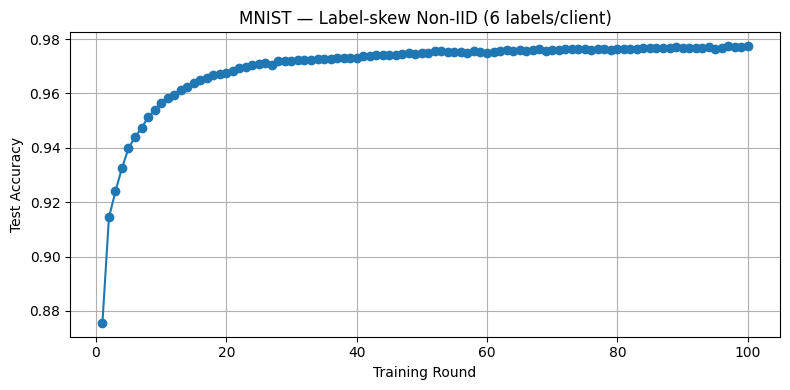


Saved metrics to: mnist_label_noniid_6labels_metrics.csv
Saved plot to:    mnist_label_noniid_6labels_accuracy_vs_round.png
FMNIST | iid | Round 01 | test_acc=0.8146 | test_loss=0.5291 | avg_local_loss=0.7341
FMNIST | iid | Round 02 | test_acc=0.8309 | test_loss=0.4686 | avg_local_loss=0.4901
FMNIST | iid | Round 03 | test_acc=0.8445 | test_loss=0.4359 | avg_local_loss=0.4335
FMNIST | iid | Round 04 | test_acc=0.8499 | test_loss=0.4164 | avg_local_loss=0.4010
FMNIST | iid | Round 05 | test_acc=0.8578 | test_loss=0.3999 | avg_local_loss=0.3786
FMNIST | iid | Round 06 | test_acc=0.8611 | test_loss=0.3879 | avg_local_loss=0.3605
FMNIST | iid | Round 07 | test_acc=0.8619 | test_loss=0.3792 | avg_local_loss=0.3469
FMNIST | iid | Round 08 | test_acc=0.8637 | test_loss=0.3769 | avg_local_loss=0.3341
FMNIST | iid | Round 09 | test_acc=0.8674 | test_loss=0.3668 | avg_local_loss=0.3236
FMNIST | iid | Round 10 | test_acc=0.8699 | test_loss=0.3584 | avg_local_loss=0.3144
FMNIST | iid | Round 11 |

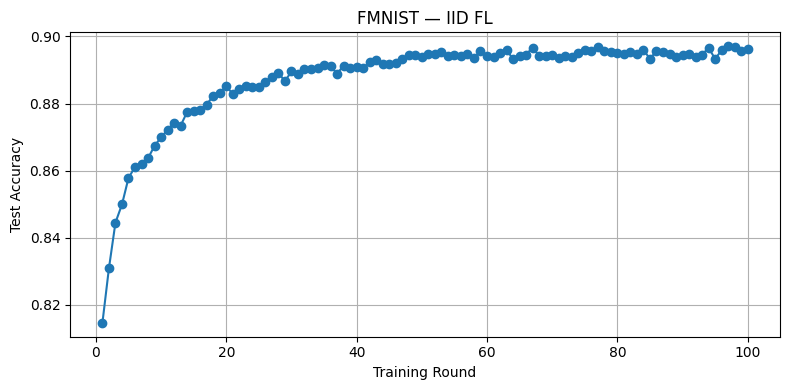


Saved metrics to: fmnist_iid_metrics.csv
Saved plot to:    fmnist_iid_accuracy_vs_round.png
FMNIST | label_noniid | Round 01 | test_acc=0.3474 | test_loss=2.1719 | avg_local_loss=0.0103
FMNIST | label_noniid | Round 02 | test_acc=0.4168 | test_loss=2.0393 | avg_local_loss=0.0071
FMNIST | label_noniid | Round 03 | test_acc=0.4976 | test_loss=1.9237 | avg_local_loss=0.0057
FMNIST | label_noniid | Round 04 | test_acc=0.5833 | test_loss=1.8333 | avg_local_loss=0.0050
FMNIST | label_noniid | Round 05 | test_acc=0.5891 | test_loss=1.7517 | avg_local_loss=0.0046
FMNIST | label_noniid | Round 06 | test_acc=0.5479 | test_loss=1.6968 | avg_local_loss=0.0042
FMNIST | label_noniid | Round 07 | test_acc=0.4287 | test_loss=1.6934 | avg_local_loss=0.0041
FMNIST | label_noniid | Round 08 | test_acc=0.5299 | test_loss=1.8667 | avg_local_loss=0.0041
FMNIST | label_noniid | Round 09 | test_acc=0.5667 | test_loss=1.6611 | avg_local_loss=0.0044
FMNIST | label_noniid | Round 10 | test_acc=0.4934 | test_los

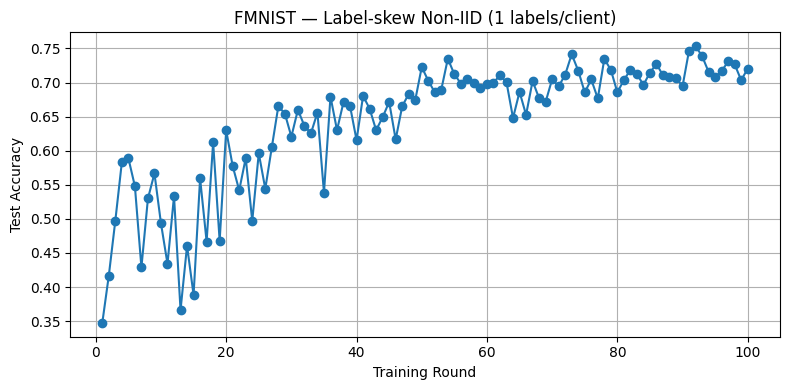


Saved metrics to: fmnist_label_noniid_1labels_metrics.csv
Saved plot to:    fmnist_label_noniid_1labels_accuracy_vs_round.png
FMNIST | label_noniid | Round 01 | test_acc=0.3763 | test_loss=1.8686 | avg_local_loss=0.0654
FMNIST | label_noniid | Round 02 | test_acc=0.5308 | test_loss=1.4815 | avg_local_loss=0.0576
FMNIST | label_noniid | Round 03 | test_acc=0.5727 | test_loss=1.2408 | avg_local_loss=0.0519
FMNIST | label_noniid | Round 04 | test_acc=0.6598 | test_loss=1.0888 | avg_local_loss=0.0452
FMNIST | label_noniid | Round 05 | test_acc=0.6463 | test_loss=1.0158 | avg_local_loss=0.0441
FMNIST | label_noniid | Round 06 | test_acc=0.6779 | test_loss=0.9479 | avg_local_loss=0.0405
FMNIST | label_noniid | Round 07 | test_acc=0.6710 | test_loss=0.9135 | avg_local_loss=0.0427
FMNIST | label_noniid | Round 08 | test_acc=0.6928 | test_loss=0.8713 | avg_local_loss=0.0384
FMNIST | label_noniid | Round 09 | test_acc=0.6976 | test_loss=0.8289 | avg_local_loss=0.0357
FMNIST | label_noniid | Rou

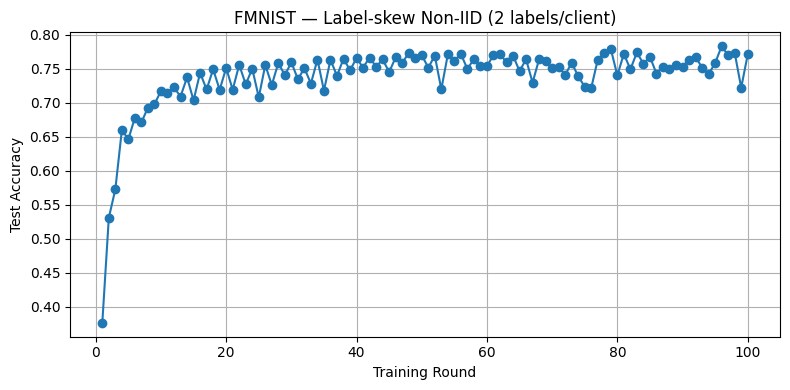


Saved metrics to: fmnist_label_noniid_2labels_metrics.csv
Saved plot to:    fmnist_label_noniid_2labels_accuracy_vs_round.png
FMNIST | label_noniid | Round 01 | test_acc=0.5538 | test_loss=1.3005 | avg_local_loss=0.2961
FMNIST | label_noniid | Round 02 | test_acc=0.6936 | test_loss=0.8497 | avg_local_loss=0.2436
FMNIST | label_noniid | Round 03 | test_acc=0.7784 | test_loss=0.6779 | avg_local_loss=0.2179
FMNIST | label_noniid | Round 04 | test_acc=0.8029 | test_loss=0.5950 | avg_local_loss=0.2014
FMNIST | label_noniid | Round 05 | test_acc=0.8125 | test_loss=0.5616 | avg_local_loss=0.1887
FMNIST | label_noniid | Round 06 | test_acc=0.8235 | test_loss=0.5305 | avg_local_loss=0.1800
FMNIST | label_noniid | Round 07 | test_acc=0.8305 | test_loss=0.5158 | avg_local_loss=0.1722
FMNIST | label_noniid | Round 08 | test_acc=0.8328 | test_loss=0.4903 | avg_local_loss=0.1663
FMNIST | label_noniid | Round 09 | test_acc=0.8346 | test_loss=0.4799 | avg_local_loss=0.1605
FMNIST | label_noniid | Rou

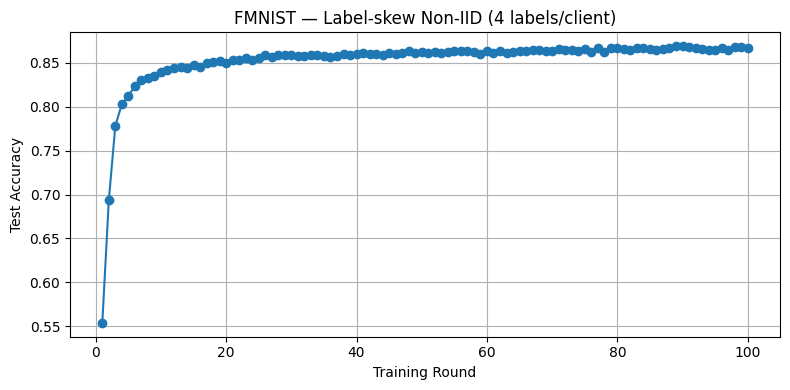


Saved metrics to: fmnist_label_noniid_4labels_metrics.csv
Saved plot to:    fmnist_label_noniid_4labels_accuracy_vs_round.png
FMNIST | label_noniid | Round 01 | test_acc=0.7343 | test_loss=0.8512 | avg_local_loss=0.4553
FMNIST | label_noniid | Round 02 | test_acc=0.8171 | test_loss=0.5673 | avg_local_loss=0.3479
FMNIST | label_noniid | Round 03 | test_acc=0.8308 | test_loss=0.4957 | avg_local_loss=0.3079
FMNIST | label_noniid | Round 04 | test_acc=0.8406 | test_loss=0.4632 | avg_local_loss=0.2850
FMNIST | label_noniid | Round 05 | test_acc=0.8428 | test_loss=0.4466 | avg_local_loss=0.2687
FMNIST | label_noniid | Round 06 | test_acc=0.8501 | test_loss=0.4244 | avg_local_loss=0.2545
FMNIST | label_noniid | Round 07 | test_acc=0.8543 | test_loss=0.4142 | avg_local_loss=0.2442
FMNIST | label_noniid | Round 08 | test_acc=0.8542 | test_loss=0.4118 | avg_local_loss=0.2351
FMNIST | label_noniid | Round 09 | test_acc=0.8592 | test_loss=0.3972 | avg_local_loss=0.2274
FMNIST | label_noniid | Rou

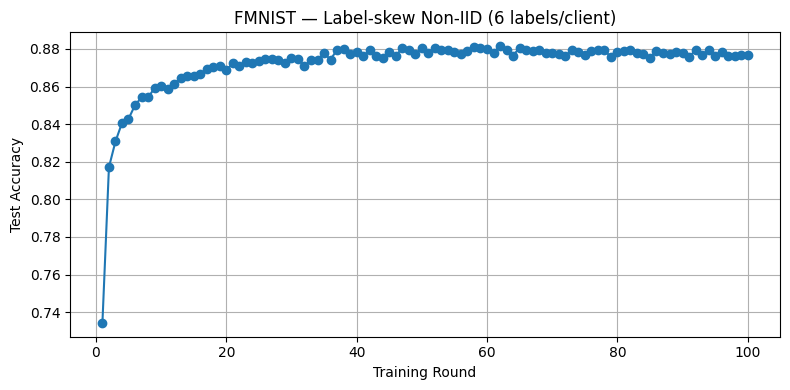


Saved metrics to: fmnist_label_noniid_6labels_metrics.csv
Saved plot to:    fmnist_label_noniid_6labels_accuracy_vs_round.png
Files already downloaded and verified
Files already downloaded and verified
CIFAR10 | iid | Round 01 | test_acc=0.3135 | test_loss=1.9893 | avg_local_loss=2.0203
CIFAR10 | iid | Round 02 | test_acc=0.3516 | test_loss=1.8459 | avg_local_loss=1.8828
CIFAR10 | iid | Round 03 | test_acc=0.3916 | test_loss=1.7574 | avg_local_loss=1.7939
CIFAR10 | iid | Round 04 | test_acc=0.3775 | test_loss=1.7581 | avg_local_loss=1.7354
CIFAR10 | iid | Round 05 | test_acc=0.3945 | test_loss=1.6944 | avg_local_loss=1.6869
CIFAR10 | iid | Round 06 | test_acc=0.4219 | test_loss=1.6430 | avg_local_loss=1.6525
CIFAR10 | iid | Round 07 | test_acc=0.4150 | test_loss=1.6615 | avg_local_loss=1.6303
CIFAR10 | iid | Round 08 | test_acc=0.4245 | test_loss=1.6270 | avg_local_loss=1.5950
CIFAR10 | iid | Round 09 | test_acc=0.3843 | test_loss=1.7031 | avg_local_loss=1.5672
CIFAR10 | iid | Round 1

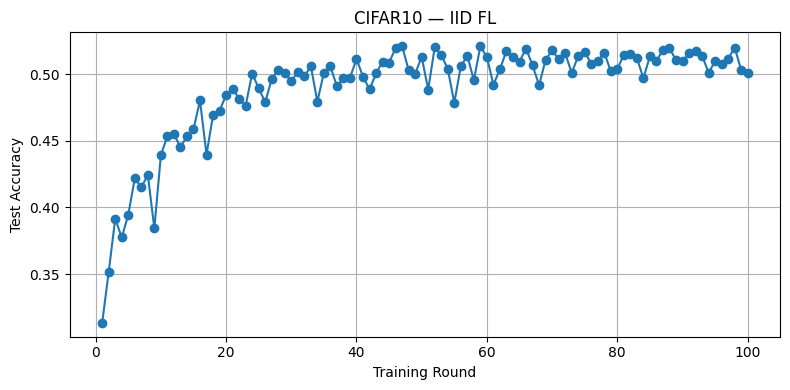


Saved metrics to: cifar10_iid_metrics.csv
Saved plot to:    cifar10_iid_accuracy_vs_round.png
Files already downloaded and verified
Files already downloaded and verified
CIFAR10 | label_noniid | Round 01 | test_acc=0.1165 | test_loss=2.2776 | avg_local_loss=0.0069
CIFAR10 | label_noniid | Round 02 | test_acc=0.1521 | test_loss=2.2581 | avg_local_loss=0.0061
CIFAR10 | label_noniid | Round 03 | test_acc=0.1095 | test_loss=2.2442 | avg_local_loss=0.0060
CIFAR10 | label_noniid | Round 04 | test_acc=0.1403 | test_loss=2.2597 | avg_local_loss=0.0059
CIFAR10 | label_noniid | Round 05 | test_acc=0.1164 | test_loss=2.2440 | avg_local_loss=0.0059
CIFAR10 | label_noniid | Round 06 | test_acc=0.1476 | test_loss=2.3158 | avg_local_loss=0.0058
CIFAR10 | label_noniid | Round 07 | test_acc=0.1680 | test_loss=2.4275 | avg_local_loss=0.0060
CIFAR10 | label_noniid | Round 08 | test_acc=0.1654 | test_loss=2.3560 | avg_local_loss=0.0063
CIFAR10 | label_noniid | Round 09 | test_acc=0.1209 | test_loss=2.358

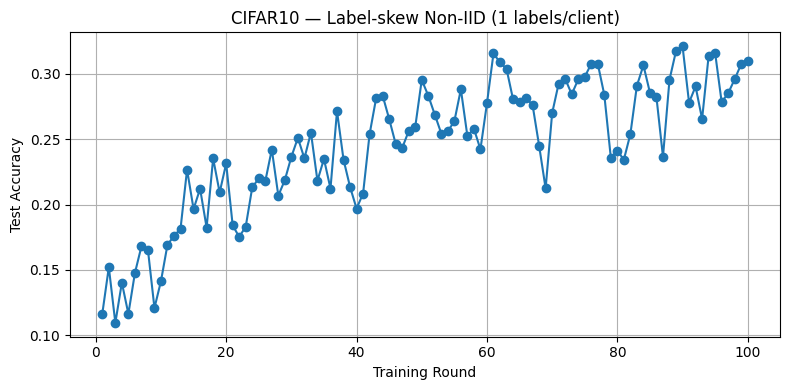


Saved metrics to: cifar10_label_noniid_1labels_metrics.csv
Saved plot to:    cifar10_label_noniid_1labels_accuracy_vs_round.png
Files already downloaded and verified
Files already downloaded and verified
CIFAR10 | label_noniid | Round 01 | test_acc=0.1042 | test_loss=2.3057 | avg_local_loss=0.9289
CIFAR10 | label_noniid | Round 02 | test_acc=0.1000 | test_loss=2.3089 | avg_local_loss=0.9146
CIFAR10 | label_noniid | Round 03 | test_acc=0.0999 | test_loss=2.3118 | avg_local_loss=0.9013
CIFAR10 | label_noniid | Round 04 | test_acc=0.1007 | test_loss=2.3092 | avg_local_loss=0.9052
CIFAR10 | label_noniid | Round 05 | test_acc=0.0948 | test_loss=2.3033 | avg_local_loss=0.9288
CIFAR10 | label_noniid | Round 06 | test_acc=0.0993 | test_loss=2.3028 | avg_local_loss=0.9299
CIFAR10 | label_noniid | Round 07 | test_acc=0.1000 | test_loss=2.3049 | avg_local_loss=0.9174
CIFAR10 | label_noniid | Round 08 | test_acc=0.1000 | test_loss=2.3029 | avg_local_loss=0.9283
CIFAR10 | label_noniid | Round 09 |

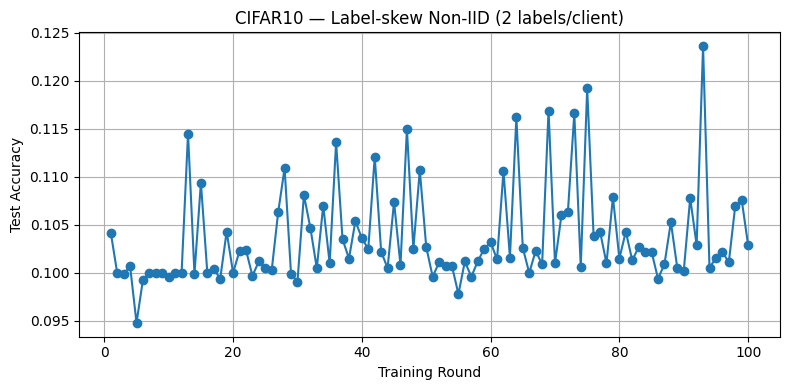


Saved metrics to: cifar10_label_noniid_2labels_metrics.csv
Saved plot to:    cifar10_label_noniid_2labels_accuracy_vs_round.png
Files already downloaded and verified
Files already downloaded and verified
CIFAR10 | label_noniid | Round 01 | test_acc=0.1329 | test_loss=2.2903 | avg_local_loss=1.3701
CIFAR10 | label_noniid | Round 02 | test_acc=0.1771 | test_loss=2.2733 | avg_local_loss=1.3559
CIFAR10 | label_noniid | Round 03 | test_acc=0.1973 | test_loss=2.1874 | avg_local_loss=1.2822
CIFAR10 | label_noniid | Round 04 | test_acc=0.2526 | test_loss=2.1140 | avg_local_loss=1.2172
CIFAR10 | label_noniid | Round 05 | test_acc=0.2605 | test_loss=2.0822 | avg_local_loss=1.1773
CIFAR10 | label_noniid | Round 06 | test_acc=0.2926 | test_loss=2.0246 | avg_local_loss=1.1252
CIFAR10 | label_noniid | Round 07 | test_acc=0.2775 | test_loss=1.9964 | avg_local_loss=1.0939
CIFAR10 | label_noniid | Round 08 | test_acc=0.3061 | test_loss=1.9596 | avg_local_loss=1.0732
CIFAR10 | label_noniid | Round 09 |

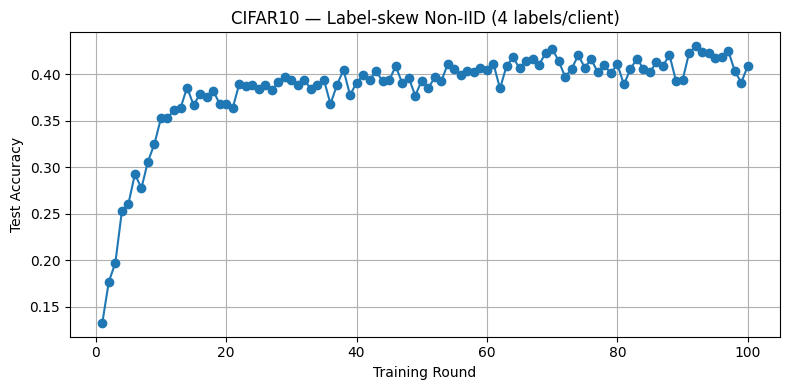


Saved metrics to: cifar10_label_noniid_4labels_metrics.csv
Saved plot to:    cifar10_label_noniid_4labels_accuracy_vs_round.png
Files already downloaded and verified
Files already downloaded and verified
CIFAR10 | label_noniid | Round 01 | test_acc=0.1876 | test_loss=2.2516 | avg_local_loss=1.6300
CIFAR10 | label_noniid | Round 02 | test_acc=0.2558 | test_loss=2.1251 | avg_local_loss=1.5681
CIFAR10 | label_noniid | Round 03 | test_acc=0.3474 | test_loss=1.8872 | avg_local_loss=1.4698
CIFAR10 | label_noniid | Round 04 | test_acc=0.3459 | test_loss=1.8426 | avg_local_loss=1.4045
CIFAR10 | label_noniid | Round 05 | test_acc=0.3406 | test_loss=1.8586 | avg_local_loss=1.3793
CIFAR10 | label_noniid | Round 06 | test_acc=0.3663 | test_loss=1.7682 | avg_local_loss=1.3392
CIFAR10 | label_noniid | Round 07 | test_acc=0.3972 | test_loss=1.6867 | avg_local_loss=1.3045
CIFAR10 | label_noniid | Round 08 | test_acc=0.3756 | test_loss=1.7573 | avg_local_loss=1.2872
CIFAR10 | label_noniid | Round 09 |

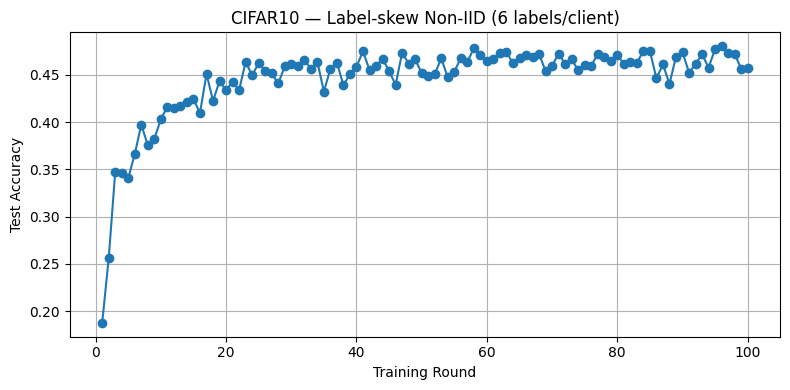


Saved metrics to: cifar10_label_noniid_6labels_metrics.csv
Saved plot to:    cifar10_label_noniid_6labels_accuracy_vs_round.png


In [107]:
# MNIST
df_mnist_iid = run_federated_experiment("mnist", "iid", device=device)
df_mnist_1label = run_federated_experiment("mnist", "label_noniid", device=device, labels_per_client=1)
df_mnist_2labels = run_federated_experiment("mnist", "label_noniid", device=device, labels_per_client=2)
df_mnist_4labels = run_federated_experiment("mnist", "label_noniid", device=device, labels_per_client=4)
df_mnist_6labels = run_federated_experiment("mnist", "label_noniid", device=device, labels_per_client=6)

# FMNIST
df_fmnist_iid = run_federated_experiment("fmnist", "iid", device=device)
df_fmnist_1label = run_federated_experiment("fmnist", "label_noniid", device=device, labels_per_client=1)
df_fmnist_2labels = run_federated_experiment("fmnist", "label_noniid", device=device, labels_per_client=2)
df_fmnist_4labels = run_federated_experiment("fmnist", "label_noniid", device=device, labels_per_client=4)
df_fmnist_6labels = run_federated_experiment("fmnist", "label_noniid", device=device, labels_per_client=6)

# CIFAR10
df_cifar10_iid = run_federated_experiment("cifar10", "iid", device=device)
df_cifar10_1label = run_federated_experiment("cifar10", "label_noniid", device=device, labels_per_client=1)
df_cifar10_2labels = run_federated_experiment("cifar10", "label_noniid", device=device, labels_per_client=2)
df_cifar10_4labels = run_federated_experiment("cifar10", "label_noniid", device=device, labels_per_client=4)
df_cifar10_6labels = run_federated_experiment("cifar10", "label_noniid", device=device, labels_per_client=6)

Cell 15: MNIST comparison graph

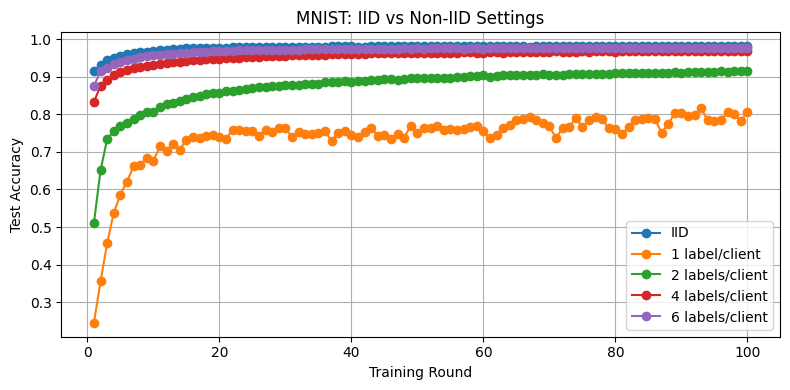

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_mnist_iid["round"], df_mnist_iid["test_accuracy"], marker="o", label="IID")
plt.plot(df_mnist_1label["round"], df_mnist_1label["test_accuracy"], marker="o", label="1 label/client")
plt.plot(df_mnist_2labels["round"], df_mnist_2labels["test_accuracy"], marker="o", label="2 labels/client")
plt.plot(df_mnist_4labels["round"], df_mnist_4labels["test_accuracy"], marker="o", label="4 labels/client")
plt.plot(df_mnist_6labels["round"], df_mnist_6labels["test_accuracy"], marker="o", label="6 labels/client")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("MNIST: IID vs Non-IID Settings")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("mnist_iid_vs_noniid_comparison.png")
plt.show()

Cell 16: 2. FMNIST comparison graph

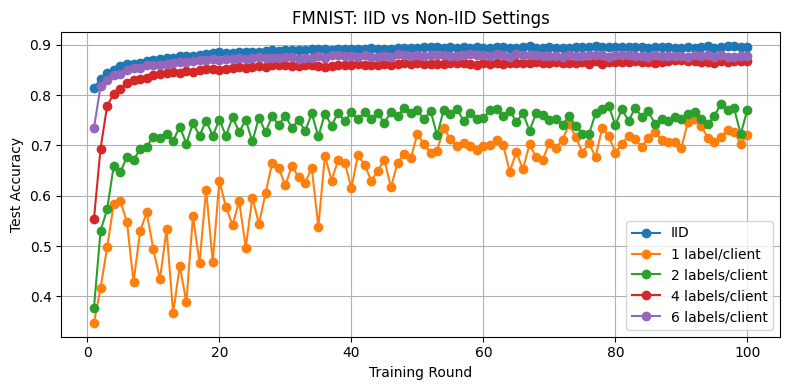

In [109]:
plt.figure(figsize=(8, 4))
plt.plot(df_fmnist_iid["round"], df_fmnist_iid["test_accuracy"], marker="o", label="IID")
plt.plot(df_fmnist_1label["round"], df_fmnist_1label["test_accuracy"], marker="o", label="1 label/client")
plt.plot(df_fmnist_2labels["round"], df_fmnist_2labels["test_accuracy"], marker="o", label="2 labels/client")
plt.plot(df_fmnist_4labels["round"], df_fmnist_4labels["test_accuracy"], marker="o", label="4 labels/client")
plt.plot(df_fmnist_6labels["round"], df_fmnist_6labels["test_accuracy"], marker="o", label="6 labels/client")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("FMNIST: IID vs Non-IID Settings")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("fmnist_iid_vs_noniid_comparison.png")
plt.show()

Cell 17: CIFAR10 comparison graph

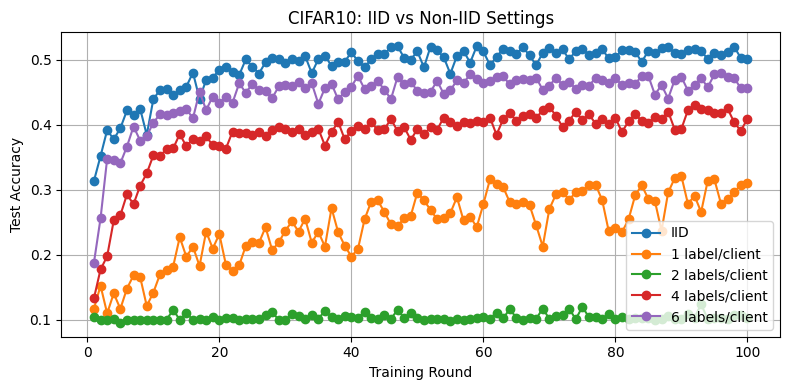

In [110]:
plt.figure(figsize=(8, 4))
plt.plot(df_cifar10_iid["round"], df_cifar10_iid["test_accuracy"], marker="o", label="IID")
plt.plot(df_cifar10_1label["round"], df_cifar10_1label["test_accuracy"], marker="o", label="1 label/client")
plt.plot(df_cifar10_2labels["round"], df_cifar10_2labels["test_accuracy"], marker="o", label="2 labels/client")
plt.plot(df_cifar10_4labels["round"], df_cifar10_4labels["test_accuracy"], marker="o", label="4 labels/client")
plt.plot(df_cifar10_6labels["round"], df_cifar10_6labels["test_accuracy"], marker="o", label="6 labels/client")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("CIFAR10: IID vs Non-IID Settings")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar10_iid_vs_noniid_comparison.png")
plt.show()

Cell 18: 4. IID comparison across datasets

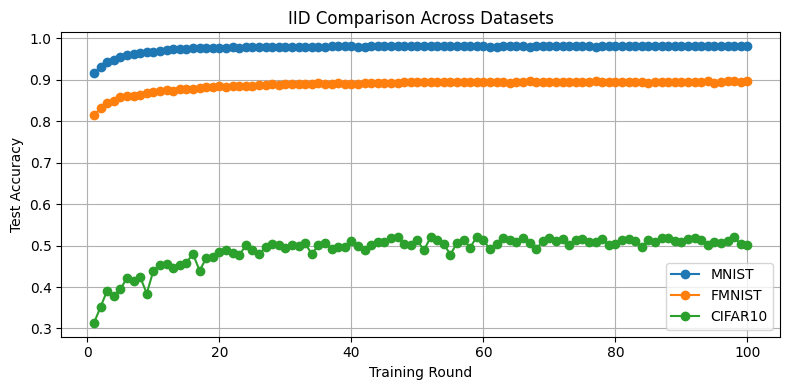

In [111]:
plt.figure(figsize=(8, 4))
plt.plot(df_mnist_iid["round"], df_mnist_iid["test_accuracy"], marker="o", label="MNIST")
plt.plot(df_fmnist_iid["round"], df_fmnist_iid["test_accuracy"], marker="o", label="FMNIST")
plt.plot(df_cifar10_iid["round"], df_cifar10_iid["test_accuracy"], marker="o", label="CIFAR10")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("IID Comparison Across Datasets")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("iid_across_datasets_comparison.png")
plt.show()

Cell 19: 5. 1-label comparison across datasets

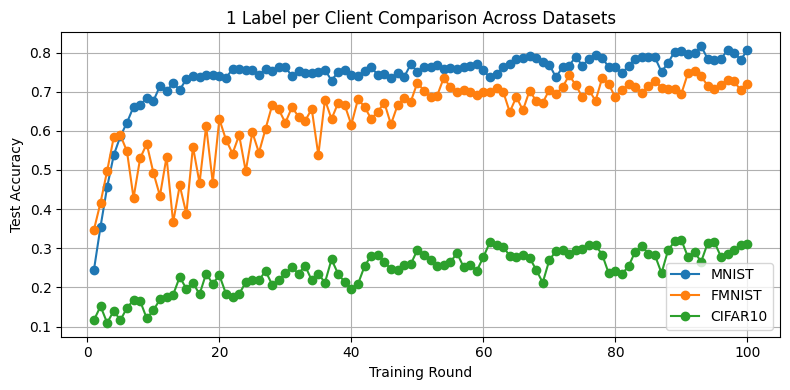

In [112]:
plt.figure(figsize=(8, 4))
plt.plot(df_mnist_1label["round"], df_mnist_1label["test_accuracy"], marker="o", label="MNIST")
plt.plot(df_fmnist_1label["round"], df_fmnist_1label["test_accuracy"], marker="o", label="FMNIST")
plt.plot(df_cifar10_1label["round"], df_cifar10_1label["test_accuracy"], marker="o", label="CIFAR10")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("1 Label per Client Comparison Across Datasets")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("1label_across_datasets_comparison.png")
plt.show()

Cell 20: 6. 2-label comparison across datasets

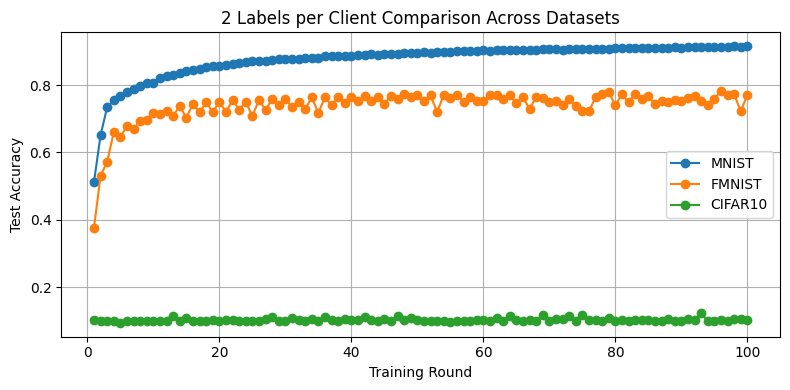

In [113]:
plt.figure(figsize=(8, 4))
plt.plot(df_mnist_2labels["round"], df_mnist_2labels["test_accuracy"], marker="o", label="MNIST")
plt.plot(df_fmnist_2labels["round"], df_fmnist_2labels["test_accuracy"], marker="o", label="FMNIST")
plt.plot(df_cifar10_2labels["round"], df_cifar10_2labels["test_accuracy"], marker="o", label="CIFAR10")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("2 Labels per Client Comparison Across Datasets")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("2labels_across_datasets_comparison.png")
plt.show()

Cell 21: 4-label comparison across datasets

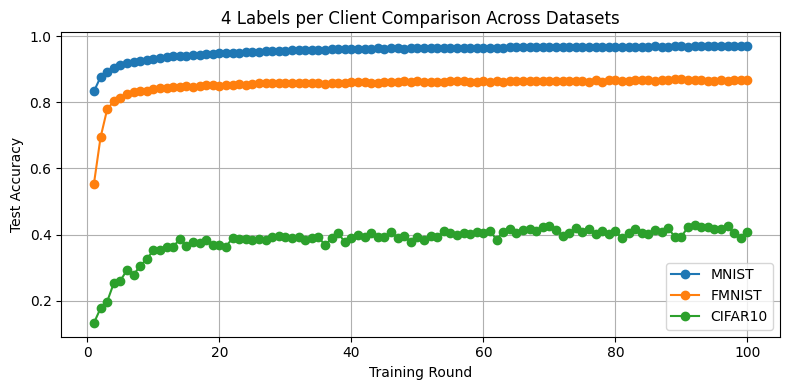

In [114]:
plt.figure(figsize=(8, 4))
plt.plot(df_mnist_4labels["round"], df_mnist_4labels["test_accuracy"], marker="o", label="MNIST")
plt.plot(df_fmnist_4labels["round"], df_fmnist_4labels["test_accuracy"], marker="o", label="FMNIST")
plt.plot(df_cifar10_4labels["round"], df_cifar10_4labels["test_accuracy"], marker="o", label="CIFAR10")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("4 Labels per Client Comparison Across Datasets")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("4labels_across_datasets_comparison.png")
plt.show()

Cell 22: 6-label comparison across datasets

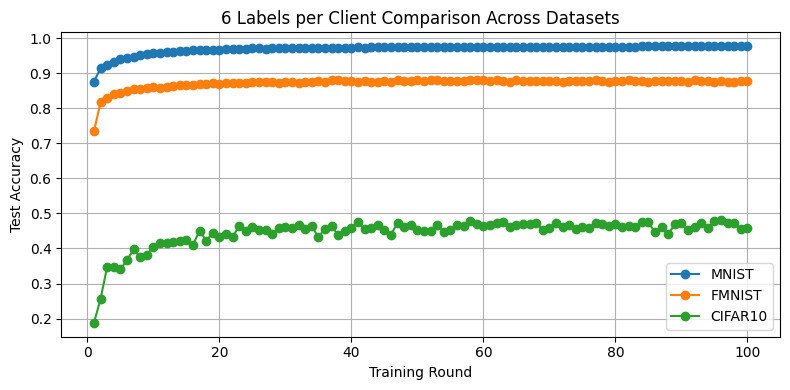

In [115]:
plt.figure(figsize=(8, 4))
plt.plot(df_mnist_6labels["round"], df_mnist_6labels["test_accuracy"], marker="o", label="MNIST")
plt.plot(df_fmnist_6labels["round"], df_fmnist_6labels["test_accuracy"], marker="o", label="FMNIST")
plt.plot(df_cifar10_6labels["round"], df_cifar10_6labels["test_accuracy"], marker="o", label="CIFAR10")

plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("6 Labels per Client Comparison Across Datasets")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("6labels_across_datasets_comparison.png")
plt.show()